# Predicting Next-Week Adult Female Salmon Lice Levels in Norwegian Aquaculture
## Project objective
This project develops and evaluates a machine-learning workflow for predicting next-week adult female salmon lice levels at Norwegian aquaculture localities using weekly public data from BarentsWatch.

The main modelling question is:
## Can a supervised machine-learning model improve one-week-ahead predictions compared with a simple persistence baseline that assumes next week's lice level will be the same as the current week's level?

The analysis focuses on active salmonid localities with valid weekly lice reports and compares several regression models using a time-based train-validation-test design

## Data source
Weekly locality-level fish-health data were obtained from the BarentsWatch Fish Health API for 2012–2026.

The raw data include locality information, salmon lice measurements, sea temperature, treatment information and locality status.

The main variables used in the modelling workflow are:
- 'adult_female_lice': current-week adult female lice level
- 'mobile_lice': current-week mobile lice level
- 'stationary_lice': current-week stationary lice level
- 'sea_temperature': reported sea temperature
- 'n_treatments': number of registered treatments
- 'week': ISO week of year

The prediction target is the adult female lice level at the same locality in the following calendar week.

# processing logic:
Raw JSON -> Combine weekly records -> Standardise column names -> Filter modelling population -> Data-quality checks -> Construct calendar week date -> Construct next-week target

## Modelling population
The modelling dataset was restricted to locality-weeks that:
1. had a salmonid aquaculture licence,
2. were not classified as fallow,
3. had a valid lice report.
This avoids treating structurally missing lice measurements as zero and ensures that the model is trained only on weeks with valid observed lice levels
## Sea-temperature quality control
A small number of sea-temperature observations contained implausibly high values. Because the underlying error mechanism could not be established reliably, these values were not manually corrected. Instead, temperatures above 25°C were treated as missing for modelling.
## Next-week target
The data contain gaps in reporting and locality activity. Therefore, simply shifting each locality's observations by one row could incorrectly pair observations that were two or more weeks apart.

ISO calendar dates were created for each locality-week, and only observations whose next valid record occurred exactly seven days later were retained.
## feature & target
The initial feature set contained current-week information only:
- adult female lice
- mobile lice
- stationary lice
- sea temperature
- number of treatments
- week of year
'total_lice' was excluded.
## ## time-based train, validation and test split
Because this is a time_series based forecasting problem, random train-test splitting was avoided.
The data were separated:
- **Training:** 2012–2022
- **Validation:** 2023–2024
- **Test:** 2025
- **Out-of-time evaluation:** available weeks of 2026


In [ ]:
# Download data from API including week 1-52
from pathlib import Path
from getpass import getpass
import requests
import json
from datetime import date 
import time
raw_dir = Path("/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/raw/barentswatch_api")
raw_dir.mkdir(parents=True, exist_ok=True)
client_id = input("Enter client ID: ")
client_secret = getpass("Enter client secret: ")
def get_token():
    response=requests.post(
    "https://id.barentswatch.no/connect/token",
    data = {
    "grant_type": "client_credentials",
    "client_id": client_id,
    "client_secret": client_secret,
    "scope": "api"})
    response.raise_for_status()
    return response.json()['access_token']
token=get_token()
print('token obtained successfully') 


token obtained successfully


In [ ]:
def download_week(year, week, token):
    url = ("https://www.barentswatch.no/bwapi/"
           f"v2/geodata/fishhealth/locality/{year}/{week}")
    headers={"Authorization": f"Bearer {token}", 
             'Content-Type': 'application/json'}
    response=requests.post(url, headers=headers, 
                          json={},
                          timeout=60)
    return response

In [ ]:
def last_iso_week(year):
    return date(year, 12, 28).isocalendar().week
for year in range(2012, 2027):
    if year==2026: 
        final_week=33
    else:
        final_week=last_iso_week(year)
    print(f'\nDownloading{year}:week 1-{final_week}')
    for week in range(1, final_week+1):
        outfile=raw_dir / f'fishhealth_{year}_{week:02d}.json'
        if outfile.exists():
            print(f'{year} W{week:02d}: already downloaded')
            continue
        response=download_week(year, week, token)
        if response.status_code==401:
            print('toke expired, getting new token')
            token=get_token()
            response=download_week(year, week, token)
        if response.status_code==200:
            data=response.json()
            with open(outfile, 'w', encoding='utf-8') as f:
                json.dump(data, f, ensure_ascii=False)
            print(f'{year} W{week:02d}'
            f'{len(data)} localities')
        else:
            print (f'error{year} W({week:02d}:'
                   f'{response.status_code}')
            print(response.text[:500])

In [ ]:
import json 
import pandas as pd
from pathlib import Path
raw_dir=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/raw/barentswatch_api')
rows=[]
for file in raw_dir.glob('fishhealth_*.json'):
    parts=file.stem.split('_')
    year=int(parts[1])
    week=int(parts[2])
    with open(file, 'r', encoding='utf-8') as f:
        data=json.load(f)
    for x in data:
        locality=x.get('locality', {})
        municipality=x.get('municipality',{})
        geometry=x.get('geometry', {})
        lice=x.get('liceReport', {})
        coords=geometry.get('coordinates', [None, None])
        rows.append({'year': year,
                     'week': week,
                     'locality_week_id': x.get('localityWeekId'),
                     'locality_no': locality.get('no'),
                     'locality_name': locality.get('name'), 
                     'municipality_no': municipality.get('no'),
                     'municipality_name': municipality.get('name'), 
                     'longitude': coords[0] if len(coords) >0 else None,
                     'latitude': coords[1] if len(coords) > 1 else None, 
                     'has_salmonoid_license': x.get('hasSalmonoidLicense'),
                     'is_slaughter_holding_cage': x.get('isSlaughterHoldingCage'), 
                     'has_reported': lice.get('hasReported'),
                     'is_fallow': lice.get('isFallow'),
                     'adult_female_lice': lice.get('adultFemaleLice', {}).get('average'),
                     'mobile_lice': lice.get('mobileLice', {}).get('average'),
                     'stationary_lice': lice.get('stationaryLice', {}).get('average'),
                     'total_lice': lice.get('totalLice',{}).get('average'), 
                     'sea_temperature': lice.get('seaTemperature'), 
                     'n_treatments': len(x.get('liceTreatments', [])),
                     'n_diseases': len(x.get('diseases', []))}) 
df=pd.DataFrame(rows) #NB!: be careful about the indentation of this line, it should be outside the for loop, otherwise, the running time will be endless long
print(df.shape)
df.head()
df.info()
sorted(df['year'].unique())

In [ ]:
year_summary=df.groupby('year').agg(
    rows=('locality_no', 'size'),
    localities=('locality_no', 'nunique'), 
    weeks=('week', 'nunique'),
    reported=('has_reported', 'sum'),
    lice_nonmissing=('adult_female_lice', 'count'),
    temperature_nonmissing=('sea_temperature', 'count'))
year_summary['reported_pct']=(year_summary['reported']/year_summary['rows']*100)
year_summary['temperature_pct']=(year_summary['temperature_nonmissing']/year_summary['rows']*100)
year_summary.round(1)
#check report difference, we are interested in has_salmonoid_license==TRUE, is_fallow==FALSE, has_reported==TRUE
a=pd.crosstab(df['is_fallow'], df['has_reported'])
a

In [ ]:
model_base=df[(df['has_salmonoid_license']==True) & 
              (df['is_fallow']==False) &
              (df['has_reported']==True) 
              ]
print(model_base.shape)
model_base.groupby('year').agg(
    rows=('locality_no', 'size'),
    localities=('locality_no', 'nunique'),
    weeks=('week', 'nunique'))
model_base[
    [
        "adult_female_lice",
        "mobile_lice",
        "stationary_lice",
        "total_lice",
        "sea_temperature"
    ]
].describe() 
#here, the data distribution tend to be right skewed for all the lice variables, as the mean is larger than the median, and the max value is much larger than the 75% quantile.  
#also, the max temperature is 196.18? we mush check the data
model_base[
    [
        "adult_female_lice",
        "mobile_lice",
        "stationary_lice",
        "total_lice",
        "sea_temperature"
    ]
].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
)

model_base[model_base['sea_temperature']>25].shape
model_base.loc[
    model_base["sea_temperature"] > 25,
    [
        "year",
        "week",
        "locality_no",
        "locality_name",
        "latitude",
        "longitude",
        "sea_temperature"]].sort_values("sea_temperature", ascending=False)

temp_check = model_base.sort_values(["locality_no", "year", "week"]).copy()
temp_check["temp_prev"] = (temp_check.groupby("locality_no")["sea_temperature"].shift(1))
temp_check["temp_next"] = (temp_check.groupby("locality_no")["sea_temperature"].shift(-1))
temp_outliers = temp_check[temp_check["sea_temperature"] > 25][
    [
        "year",
        "week",
        "locality_no",
        "locality_name",
        "sea_temperature",
        "temp_prev",
        "temp_next"]]
temp_outliers.head(30)

# as it is not decided to divide the temperature by 10 for all, and the outliers are not too much, make them missing value make more sense
import numpy as np
model_base['sea_temperature_clean']=model_base['sea_temperature'].copy() 
model_base.loc[model_base['sea_temperature_clean']>25, 'sea_temperature_clean'] = np.nan
model_base["sea_temperature_clean"].isna().sum()
model_base['calculated_sea_lice']=model_base['adult_female_lice'] + model_base['mobile_lice'] + model_base['stationary_lice'] 
model_base['total_dif']=model_base['calculated_sea_lice'] - model_base['total_lice']
model_base['total_dif'].sort_values()
model_base['total_dif'].sort_values()
model_base["total_dif"].describe(percentiles=[0.90, 0.99, 0.999])

In [ ]:
# start feature engineering, as the data are time series data, we can use the previous weeks' data to predict the next week's lice level. 
# but at the same time, we need to check the data consistency, as some localities may have missing weeks, if we want to use the the current week to predict the next week 
# the model logic: model_base -> active salmonoid + reported -> temperature_clean -> 7 days gap -> model ml
model_base['week_date']=pd.to_datetime(model_base['year'].astype(str) + '-W' + model_base['week'].astype(str).str.zfill(2) + '-1', format='%G-W%V-%u') 
model_base=model_base.sort_values(['locality_no', 'week_date'])
model_base['days_to_next_record']=(model_base.groupby('locality_no')['week_date'].shift(-1) -model_base['week_date']).dt.days
model_base["adult_female_lice_next"] = (model_base.groupby("locality_no")["adult_female_lice"].shift(-1))
model_ml=model_base[(model_base['days_to_next_record']==7) & (model_base['sea_temperature_clean'].notna())]
model_ml

In [221]:
# feature engineering: create lag features
features=[
    'adult_female_lice',
    'mobile_lice',
    'stationary_lice', 
    'sea_temperature_clean', 
    'n_treatments',
    'week']
X = model_ml[features]
y = model_ml["adult_female_lice_next"]
train_data=model_ml['year']<=2022
validation_data=model_ml['year'].isin([2023, 2024])
test_data=model_ml['year']==2025 
out_of_time_data=model_ml['year']==2026 
X_train, y_train=X.loc[train_data], y.loc[train_data]
X_validation, y_validation=X.loc[validation_data], y.loc[validation_data]
X_test, y_test=X.loc[test_data], y.loc[test_data]
X_out_of_time, y_out_of_time=X.loc[out_of_time_data], y.loc[out_of_time_data]

In [ ]:
# evaluation of baseline model, create the most simple prediction model for future comparison
# baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np 
baseline_val_pred=X_validation['adult_female_lice']
baseline_val_mae=mean_absolute_error(y_validation, baseline_val_pred) 
baseline_rmse=np.sqrt(mean_squared_error(y_validation, baseline_val_pred)) 
print('baseline mae:', baseline_val_mae) #loss function, average absolute error
print('baseline rmse:', baseline_rmse) # cost function, root mean squared error

baseline mae: 0.08458571215865546
baseline rmse: 0.24842448591249322


In [ ]:
# training a simple linear regression model: 
from sklearn.linear_model import LinearRegression
linear_model=LinearRegression()
linear_model.fit(X_train, y_train)
validation_pred_linear=linear_model.predict(X_validation)
linear_val_mae=mean_absolute_error(y_validation, validation_pred_linear)
linear_val_rmse=np.sqrt(mean_squared_error(y_validation, validation_pred_linear))
print('linear_val_mae:', linear_val_mae)
print('linear_val_rmse:', linear_val_rmse)
coef_table=pd.DataFrame({'feature': X_train.columns, 
                         'coefficient': linear_model.coef_})
print(coef_table)
print('intercept:', linear_model.intercept_)
# the results show that the linear regression model has a higher mae and lower rmse than the persistence baseline model, which means the linear regression model is not a good model for this problem.

linear_val_mae: 0.09311656864324751
linear_val_rmse: 0.2241515247964826
                 feature  coefficient
0      adult_female_lice     0.549319
1            mobile_lice     0.040867
2        stationary_lice     0.006233
3  sea_temperature_clean     0.004060
4           n_treatments    -0.024460
5                   week     0.000192
intercept: 0.010391531447830976


In [ ]:
# create a nonlinear model, here we can try gradient boosting model and random forest model
from sklearn.ensemble import HistGradientBoostingRegressor 
gb_model=HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_leaf_nodes=31, random_state=42)
gb_model.fit(X_train, y_train) 
validation_pred_gb=gb_model.predict(X_validation)
gb_val_mae=mean_absolute_error(y_validation, validation_pred_gb)
gb_val_rmse=np.sqrt(mean_squared_error(y_validation, validation_pred_gb)) 
print('gb_val_mae:', gb_val_mae)
print('gb_val_rmse:', gb_val_rmse)

gb_val_mae: 0.08287168521197222
gb_val_rmse: 0.22157930027642653


In [284]:
configs = [
    {"learning_rate": 0.03, "max_iter": 300, "max_leaf_nodes": 31},
    {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 31},
    {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 63},
    {"learning_rate": 0.10, "max_iter": 100, "max_leaf_nodes": 31},
    {"learning_rate": 0.10, "max_iter": 200, "max_leaf_nodes": 31},
]
results=[]
for config in configs:
    gbtrys_model=HistGradientBoostingRegressor(
        learning_rate=config['learning_rate'],
        max_iter=config['max_iter'],
        max_leaf_nodes=config['max_leaf_nodes'],
        random_state=42)
    gbtrys_model.fit(X_train, y_train) 
    validation_pred_gbtrys=gbtrys_model.predict(X_validation)
    gb_val_mae=mean_absolute_error(y_validation, validation_pred_gbtrys)
    gb_val_rmse=np.sqrt(mean_squared_error(y_validation, validation_pred_gbtrys)) 
    results.append({
        "config": config,
        "gb_val_mae": gb_val_mae,
        "gb_val_rmse": gb_val_rmse
    })
results.append({'config': 'baseline', 'gb_val_mae': baseline_val_mae, 'gb_val_rmse': baseline_rmse})
results_df=pd.DataFrame(results)
#here we decide to use best_config = {"learning_rate": 0.1, "max_iter": 100,"max_leaf_nodes": 31}

In [283]:
from sklearn.ensemble import HistGradientBoostingRegressor 
gb_model=HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_leaf_nodes=31, random_state=42)
gb_model.fit(X_train, y_train) 
validation_pred_gb=gb_model.predict(X_validation)
gb_val_mae=mean_absolute_error(y_validation, validation_pred_gb)
gb_val_rmse=np.sqrt(mean_squared_error(y_validation, validation_pred_gb)) 
print('gb_val_mae:', gb_val_mae)
print('gb_val_rmse:', gb_val_rmse)
results=[]
results.append({'config': 'gb_model', 'val_mae': gb_val_mae, 'val_rmse': gb_val_rmse})
results.append({'config': 'baseline', 'val_mae': baseline_val_mae, 'val_rmse': baseline_rmse})

gb_val_mae: 0.08257067740764255
gb_val_rmse: 0.22382220371937647


In [ ]:
# create a random forest model for comparison 
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(
    n_estimators=100, 
    max_depth=None, 
    min_samples_leaf=2, 
    n_jobs=-1, 
    random_state=42)
rf_model.fit(X_train, y_train)
rf_model_pred=rf_model.predict(X_validation)
rf_val_mae=mean_absolute_error(y_validation, rf_model_pred)
rf_val_rmse=np.sqrt(mean_squared_error(y_validation, rf_model_pred))
print('rf_val_mae:', rf_val_mae)
print('rf_val_rmse:', rf_val_rmse)


rf_val_mae: 0.08689445476701217
rf_val_rmse: 0.23534099852133733


In [281]:
# create a random forest model for comparison 
from sklearn.ensemble import RandomForestRegressor
rf_results=[]
configs=[
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 1},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 1},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 2, 'max_features': 1},
    {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 0.8}
]
for config in configs: 
    rf_model=RandomForestRegressor(
        n_estimators=config['n_estimators'],
        max_depth=config['max_depth'],
        min_samples_leaf=config['min_samples_leaf'], 
        max_features=config['max_features'], 
        n_jobs=-1, 
        random_state=42)
    rf_model.fit(X_train, y_train)
    rf_model_pred=rf_model.predict(X_validation)
    rf_val_mae=mean_absolute_error(y_validation, rf_model_pred)
    rf_val_rmse=np.sqrt(mean_squared_error(y_validation, rf_model_pred))
    rf_results.append({
        'config': config, 'mae': rf_val_mae, 'rmse': rf_val_rmse})
    rf_results_df=pd.DataFrame(rf_results)


In [ ]:
# summary of all models
results=[]
results=[
    {'config': 'baseline', 'val_mae': baseline_val_mae, 'val_rmse': baseline_rmse},
    {'config':'linear', 'val_mae': linear_val_mae, 'val_rmse': linear_val_rmse},
    {'config': 'gb', 'val_mae': gb_val_mae, 'val_rmse': gb_val_rmse},
    {'config': 'rf', 'val_mae': rf_val_mae, 'val_rmse': rf_val_rmse} 
    ]
result_df=pd.DataFrame(results)
result_df
#therefore, here we select the gradient boosting model as the final model 

,config,val_mae,val_rmse
0,baseline,0.084586,0.248424
1,linear,0.093117,0.224152
2,gb,0.082571,0.223822
3,rf,0.083610,0.226181


In [ ]:
# test the validated model on the test set 
X_dev=pd.concat([X_train, X_validation]) #new training data set 
y_dev=pd.concat([y_train, y_validation]) #new training data set 
gb_test_model=HistGradientBoostingRegressor(max_iter= 100, learning_rate=0.1, max_leaf_nodes=31, random_state=42) 
gb_test_model.fit(X_dev, y_dev)
gb_test_pred=gb_test_model.predict(X_test)
gb_test_mae=mean_absolute_error(y_test, gb_test_pred)
gb_test_rmse=np.sqrt(mean_squared_error(y_test, gb_test_pred))
print('gb_test_mae:', gb_test_mae)
print('gb_test_rmse:', gb_test_rmse) 

baseline_test_pred=X_test['adult_female_lice']
baseline_test_mae=mean_absolute_error(y_test, baseline_test_pred)
baseline_test_rmse=np.sqrt(mean_squared_error(y_test, baseline_test_pred)) 
print("baseline_test_mae:", baseline_test_mae)
print("baseline_test_rmse:", baseline_test_rmse)

gb_test_mae: 0.09293262497898344
gb_test_rmse: 0.22391030536527803
baseline_test_mae: 0.09750736715316416
baseline_test_rmse: 0.25246409079583476


In [290]:
# test final mode on the out-of-time data, which is the data from 2026
gb_oot_pred=gb_test_model.predict(X_out_of_time)
gb_oot_mae=mean_absolute_error(y_out_of_time, gb_oot_pred)
gb_oot_rmse=np.sqrt(mean_squared_error(y_out_of_time, gb_oot_pred)) 
print('gb_oot_mae:', gb_oot_mae)
print('gb_oot_rmse:', gb_oot_rmse)
baseline_oot_pred=X_out_of_time['adult_female_lice']
baseline_oot_mae=mean_absolute_error(y_out_of_time, baseline_oot_pred)
baseline_oot_rmse=np.sqrt(mean_squared_error(y_out_of_time, baseline_oot_pred)) 
print('baseline_oot_mae:', baseline_oot_mae)
print('baseline_oot_rmse:', baseline_oot_rmse)


gb_oot_mae: 0.05443360797790959
gb_oot_rmse: 0.10979173149202559
baseline_oot_mae: 0.05439206071837963
baseline_oot_rmse: 0.12709209432850985


## model performance compare
| Dataset   | Model    |         MAE |        RMSE |
| --------- | -------- | ----------: | ----------: |
| 2025 Test | Baseline |     0.09751 |     0.25246 |
| 2025 Test | GB       | **0.09293** | **0.22391** |
| 2026 OOT  | Baseline | **0.05439** |     0.12709 |
| 2026 OOT  | GB       |     0.05443 | **0.10979** |

here: the final model tested on 2026 (1-33 weeks)，the MAE, RMSE alsmot reduced half comapred to 2025 (1-52 weeks), that is interesting. 
as lice show seasonal relevance, we can try to first cut the data of 2025 to 1-33 weeeks and compare with 2026 againt to see whether the final model is good or not


In [295]:
new_2025_1_33=((model_ml['year']==2025) & (model_ml['week']<=33)) 
X_2025_1_33=X.loc[new_2025_1_33]
y_2025_1_33=y.loc[new_2025_1_33]
gb_2025_1_33_pred=gb_test_model.predict(X_2025_1_33)
gb_2025_1_33_mae=mean_absolute_error(y_2025_1_33, gb_2025_1_33_pred)
gb_2025_1_33_rmse=np.sqrt(mean_squared_error(y_2025_1_33, gb_2025_1_33_pred))

baseline_2025_1_33_pred=X_2025_1_33['adult_female_lice']
baseline_2025_1_33_mae=mean_absolute_error(y_2025_1_33, baseline_2025_1_33_pred)
baseline_2025_1_33_rmse=np.sqrt(mean_squared_error(y_2025_1_33, baseline_2025_1_33_pred))

print('gb_2025_1_33_mae:', gb_2025_1_33_mae)
print('gb_2025_1_33_rmse:', gb_2025_1_33_rmse)
print('baseline_2025_1_33_mae:', baseline_2025_1_33_mae)
print('baseline_2025_1_33_rmse:', baseline_2025_1_33_rmse)

gb_2025_1_33_mae: 0.07305654819800268
gb_2025_1_33_rmse: 0.1763238488364956
baseline_2025_1_33_mae: 0.07530822420925624
baseline_2025_1_33_rmse: 0.19834996468615573


In [ ]:
final_model_performance=[
{'Period': '2025_whole_year', 'model': 'baseline', 'mae': baseline_test_mae, 'rmse': baseline_test_rmse}, 
{'Period': '2025_whole_year', 'model': 'gb', 'mae': gb_test_mae, 'rmse': gb_test_rmse},
{'Period': '2025_1_33', 'model': 'baseline', 'mae': baseline_2025_1_33_mae, 'rmse': baseline_2025_1_33_rmse},
{'Period': '2025_1_33', 'model': 'gb', 'mae': gb_2025_1_33_mae, 'rmse': gb_2025_1_33_rmse},
{'Period': '2026_1_33', 'model': 'baseline', 'mae': baseline_oot_mae, 'rmse': baseline_oot_rmse},
{'Period': '2026_1_33', 'model': 'gb', 'mae': gb_oot_mae, 'rmse': gb_oot_rmse}]
final_model_performance_df=pd.DataFrame(final_model_performance)
final_model_performance_df


,Period,model,mae,rmse
0,2025_whole_year,baseline,0.097507,0.252464
1,2025_whole_year,gb,0.092933,0.223910
2,2025_1_33,baseline,0.075308,0.198350
3,2025_1_33,gb,0.073057,0.176324
4,2026_1_33,baseline,0.054392,0.127092
5,2026_1_33,gb,0.054434,0.109792


In [ ]:
comparison = pd.DataFrame({
    "2025_w1_33": y_2025_1_33.describe(),
    "2026_w1_33": y_out_of_time.describe()})
print(comparison)
#up to now, we cannot say the final model perform better on 2026 than 2025, as data of 2025 tend to be less concentrated, and more extreme data
# but still, within the same data set, the final model still perform better than baseline

         2025_w1_33    2026_w1_33
count  18057.000000  16774.000000
mean       0.154809      0.119357
std        0.229513      0.158479
min        0.000000      0.000000
25%        0.025000      0.016970
50%        0.100000      0.070000
75%        0.215213      0.170000
max        8.300000      4.300000


In [322]:
# performance table
performance=pd.DataFrame([
{'Period': '2025_whole_year', 'Model': 'Persistence baseline', 'MAE': baseline_test_mae, 'RMSE': baseline_test_rmse}, 
{'Period': '2025_whole_year', 'Model': 'HistGradientBoosting', 'MAE': gb_test_mae, 'RMSE': gb_test_rmse},
{'Period': '2025_1_33', 'Model': 'Persistence baseline', 'MAE': baseline_2025_1_33_mae, 'RMSE': baseline_2025_1_33_rmse},
{'Period': '2025_1_33', 'Model': 'HistGradientBoosting', 'MAE': gb_2025_1_33_mae, 'RMSE': gb_2025_1_33_rmse},
{'Period': '2026_1_33', 'Model': 'Persistence baseline', 'MAE': baseline_oot_mae, 'RMSE': baseline_oot_rmse},
{'Period': '2026_1_33', 'Model': 'HistGradientBoosting', 'MAE': gb_oot_mae, 'RMSE': gb_oot_rmse}])
performance

improvement=pd.DataFrame({
    'Period': ['2025_whole_year', '2025_1_33', '2026_1_33'],
    'MAE_Improvement_%': [
        (baseline_test_mae - gb_test_mae)/baseline_test_mae*100, 
        (baseline_2025_1_33_mae - gb_2025_1_33_mae)/baseline_2025_1_33_mae*100, 
        (baseline_oot_mae - gb_oot_mae)/baseline_oot_mae*100], 
'RMSE_Improvement_%': [
    (baseline_test_rmse-gb_test_rmse)/baseline_test_rmse*100, 
    (baseline_2025_1_33_rmse-gb_2025_1_33_rmse)/baseline_2025_1_33_rmse*100,
    (baseline_oot_rmse-gb_oot_rmse)/baseline_oot_rmse*100]
})
improvement

,Period,MAE_Improvement_%,RMSE_Improvement_%
0,2025_whole_year,4.691689,11.310038
1,2025_1_33,2.989947,11.104673
2,2026_1_33,-0.076385,13.612462


In [ ]:
# error analysis 
error_analysis=model_ml.loc[test_data,[
    'year', 
    'week', 
    'locality_no', 
    'locality_name', 
    'adult_female_lice',
    'adult_female_lice_next',
    'sea_temperature_clean', 
    'n_treatments']]
error_analysis['gb_pred']=gb_test_pred
error_analysis['baseline_pred']=baseline_test_pred
error_analysis["gb_abs_error"] = (
    error_analysis["adult_female_lice_next"]
    - error_analysis["gb_pred"]).abs()

error_analysis["baseline_abs_error"] = (
    error_analysis["adult_female_lice_next"]
    - error_analysis["baseline_pred"]).abs()

error_analysis["error_improvement"] = (
    error_analysis["baseline_abs_error"]
    - error_analysis["gb_abs_error"])

error_analysis[
    ['gb_abs_error', 'baseline_abs_error', 'error_improvement']
].describe()

print(
    "GB better:",
    (error_analysis["error_improvement"] > 0).mean() * 100)
print(
    "Baseline better:",
    (error_analysis["error_improvement"] < 0).mean() * 100)

GB better: 48.094151309738734
Baseline better: 51.905848690261266


In [ ]:
error_analysis.sort_values(
    "error_improvement",
    ascending=False
)[
    [
        "year",
        "week",
        "locality_no",
        "locality_name",
        "adult_female_lice",
        "adult_female_lice_next",
        "baseline_pred",
        "gb_pred",
        "baseline_abs_error",
        "gb_abs_error",
        "error_improvement",
        "sea_temperature_clean",
        "n_treatments"]].head(20)

error_analysis.sort_values(
    "error_improvement",
    ascending=True
)[
    [
        "year",
        "week",
        "locality_no",
        "locality_name",
        "adult_female_lice",
        "adult_female_lice_next",
        "baseline_pred",
        "gb_pred",
        "baseline_abs_error",
        "gb_abs_error",
        "error_improvement",
        "sea_temperature_clean",
        "n_treatments"]].head(20)

,year,week,locality_no,locality_name,adult_female_lice,adult_female_lice_next,baseline_pred,gb_pred,baseline_abs_error,gb_abs_error,error_improvement,sea_temperature_clean,n_treatments
339301,2025,32,12047,Mjåneset,6.530000,0.350000,6.530000,1.616454,6.180000,1.266454,4.913546,16.040000,0
218080,2025,35,36877,Munkskjæra,4.340000,0.110000,4.340000,0.996264,4.230000,0.886264,3.343736,13.350000,1
338694,2025,32,11530,Gissøysundet S,4.620000,0.350000,4.620000,1.597099,4.270000,1.247099,3.022901,14.410000,1
293236,2025,39,31497,Toska N,4.710000,0.280000,4.710000,1.777421,4.430000,1.497421,2.932579,14.370000,0
1181436,2025,37,11534,Klungsholmen,3.640000,0.260000,3.640000,1.135158,3.380000,0.875158,2.504842,16.600000,1
1012074,2025,41,12435,Grøttingsøy,3.600000,0.280000,3.600000,1.161496,3.320000,0.881496,2.438504,13.370000,1
1129274,2025,36,12625,Bjørgan,5.870000,0.400000,5.870000,3.457266,5.470000,3.057266,2.412734,14.760000,0
1290426,2025,40,31697,Oksen,5.610000,2.610000,5.610000,1.912429,3.000000,0.697571,2.302429,14.480000,0
751337,2025,47,30977,Æsøya,3.420000,0.390000,3.420000,1.134464,3.030000,0.744464,2.285536,6.900000,1
101947,2025,34,32857,Trettholmosen,3.440000,0.270000,3.440000,1.192602,3.170000,0.922602,2.247398,14.560000,1


In [ ]:
error_analysis["lice_change"] = (
    error_analysis["adult_female_lice_next"]
    - error_analysis["adult_female_lice"])

error_analysis["change_direction"] = np.select(
    [
        error_analysis["lice_change"] < -0.05,
        error_analysis["lice_change"] > 0.05
    ],
    [
        "Decrease",
        "Increase"],
    default="Stable")

change_performance = (
    error_analysis
    .groupby("change_direction")
    .agg(
        n=("adult_female_lice_next", "size"),
        mean_change=("lice_change", "mean"),
        baseline_mae=("baseline_abs_error", "mean"),
        gb_mae=("gb_abs_error", "mean"),
        gb_better_pct=(
            "error_improvement",
            lambda x: (x > 0).mean() * 100
        )).reset_index())
change_performance

,change_direction,n,mean_change,baseline_mae,gb_mae,gb_better_pct
0,Decrease,4867,-0.253655,0.253655,0.220378,55.722211
1,Increase,6984,0.191317,0.191317,0.166303,81.887171
2,Stable,17506,0.003536,0.016670,0.028229,32.491717


In [319]:
# feature importance
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(
    gb_test_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values(
    "importance",
    ascending=False)
importance_df


,feature,importance,std
0,adult_female_lice,0.077525,0.000795
1,mobile_lice,0.010338,0.000159
4,n_treatments,0.001589,0.000076
5,week,0.000624,0.000175
2,stationary_lice,0.000324,0.000108
3,sea_temperature_clean,0.000310,0.000127


#### model visualization 

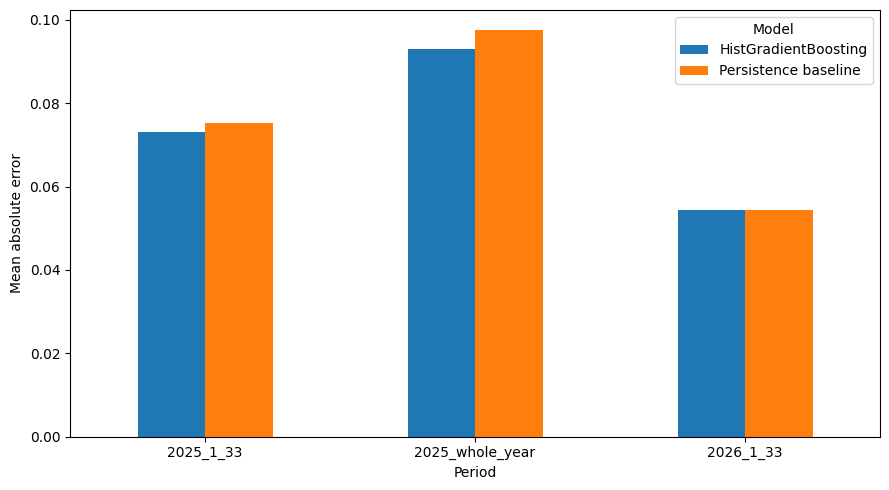

<Figure size 640x480 with 0 Axes>

In [337]:
# fig 1.1. Baseline vs HistGradientBoosting performance
import matplotlib.pyplot as plt
import seaborn as sns
fig, ax=plt.subplots(figsize=(9, 5))
performance_pivot_mae=performance.pivot(
    index='Period', 
    columns='Model',
    values='MAE')
performance_pivot_mae.plot(kind='bar', ax=ax)
ax.set_title=('MAE: Persistence baseline vs. HistGradientBoosting')
ax.set_ylabel('Mean absolute error')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig1_mae_Persistence Baseline vs HistGradientBoosting.jpg')

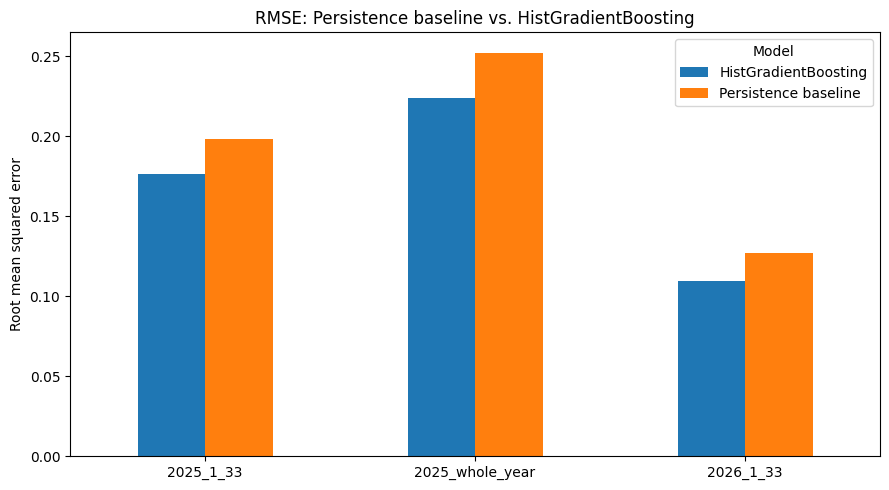

<Figure size 640x480 with 0 Axes>

In [336]:
# fig 1.2. Baseline vs HistGradientBoosting performance
fig, ax = plt.subplots(figsize=(9, 5))
performance_pivot_rmse = performance.pivot(
    index='Period',
    columns='Model',
    values='RMSE')
performance_pivot_rmse.plot(
    kind='bar',
    ax=ax)
ax.set_title('RMSE: Persistence baseline vs. HistGradientBoosting')
ax.set_ylabel('Root mean squared error') 
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig1_rmse_Persistence Baseline vs HistGradientBoosting.jpg')

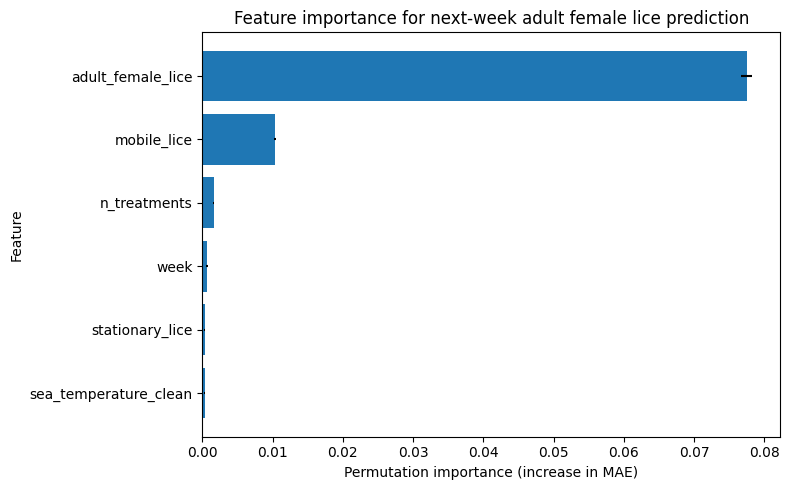

<Figure size 640x480 with 0 Axes>

In [338]:
# fig 3. feature importance plot
importance_plot=importance_df.sort_values(
    'importance', 
    ascending=True)
plt.figure(figsize=(8,5))
plt.barh(
    importance_plot['feature'],
    importance_plot['importance'],
    xerr=importance_plot['std'])
plt.xlabel('Permutation importance (increase in MAE)')
plt.ylabel('Feature')
plt.title('Feature importance for next-week adult female lice prediction')
plt.tight_layout()
plt.show()
save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig3_feature_importance.jpg')

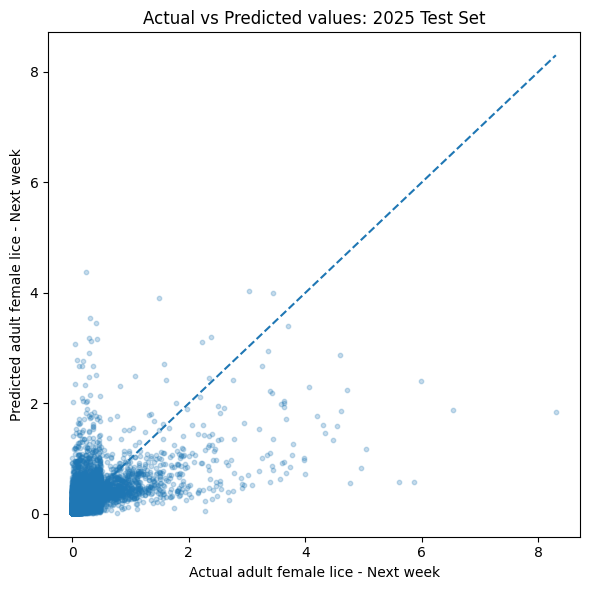

<Figure size 640x480 with 0 Axes>

In [339]:
# fig 4.1. Actual vs Predicted，based on 2025 test data
plt.figure(figsize=(6, 6))
plt.scatter(
    y_test,
    gb_test_pred,
    alpha=0.25,
    s=10)
max_value = max(y_test.max(), gb_test_pred.max())
plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--")
plt.xlabel("Actual adult female lice - Next week")
plt.ylabel("Predicted adult female lice - Next week")
plt.title("Actual vs Predicted values: 2025 Test Set")
plt.tight_layout()
plt.show()
save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig4_1_actual_vs_predicted_2025.jpg')

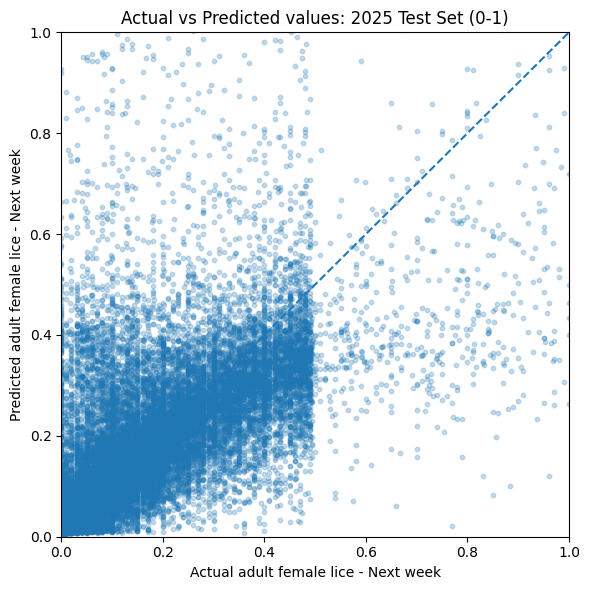

<Figure size 640x480 with 0 Axes>

In [340]:
# fig 4.2. Actual vs Predicted，based on 2025 test data(zoom in 0-1)
plt.figure(figsize=(6, 6))
plt.scatter(
    y_test,
    gb_test_pred,
    alpha=0.25,
    s=10)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Actual adult female lice - Next week")
plt.ylabel("Predicted adult female lice - Next week")
plt.title("Actual vs Predicted values: 2025 Test Set (0-1)")
plt.tight_layout()
plt.show()

save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig4_2_actual_vs_predicted_2025_zoom.jpg')

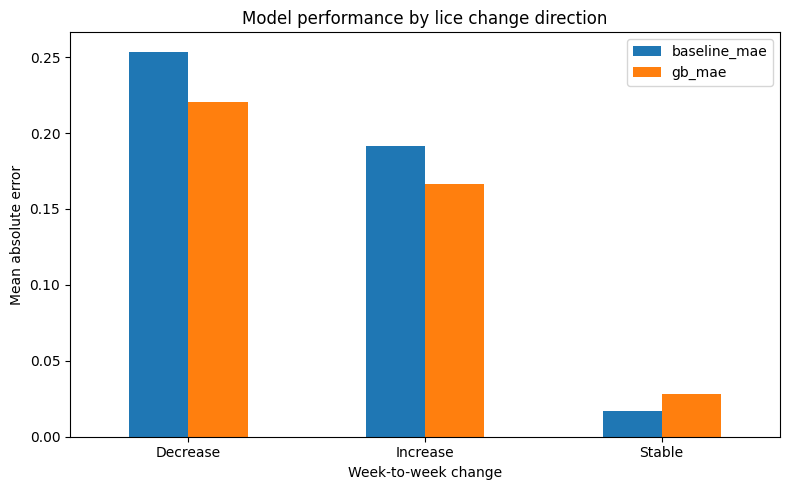

<Figure size 640x480 with 0 Axes>

In [341]:
# fig 5. error analysis 
change_plot = change_performance.set_index("change_direction")[
    ["baseline_mae", "gb_mae"]]
change_plot.plot(
    kind="bar",
    figsize=(8, 5))
plt.xlabel("Week-to-week change")
plt.ylabel("Mean absolute error")
plt.title("Model performance by lice change direction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
save_path=Path('/Users/apple/Documents/GitHub/personlig-datavitenskapsportef-lje/ML-Salmon lice/figure/')
plt.savefig(save_path / 'Fig5_error_analysis.jpg')
